# 02 - Modelltraining & Evaluation

Training eines LightGBM-Modells zur PV-Ertragsprognose:
1. Daten laden & PV-Erzeugung rekonstruieren
2. Feature Engineering
3. Modelltraining mit zeitbasiertem Split
4. Evaluation & Feature Importance
5. Modell speichern

In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.evcc_connector import get_energy_history, get_site_power
from src.data.weather_connector import get_historical
from src.features.feature_engineering import (
    build_training_dataset, reconstruct_pv_hourly, merge_weather, FEATURE_COLS
)
from src.models.pv_forecast import PVForecastModel

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Daten laden & PV rekonstruieren

In [3]:
# Energiedaten laden
energy_raw = get_energy_history()

home = energy_raw[energy_raw["source"] == "home"].copy()
home = home.sort_values("start").reset_index(drop=True)

grid = energy_raw[energy_raw["source"].str.startswith("db:3")].copy()
grid = grid.sort_values("start").reset_index(drop=True)

# Ausreißer filtern (99.5-Perzentil)
def filter_outliers(df, column, percentile=99.5):
    thresh = df[column].quantile(percentile / 100)
    return df[df[column] <= thresh].copy(), (df[column] > thresh).sum(), thresh

home, n1, _ = filter_outliers(home, "import")
grid, n2, _ = filter_outliers(grid, "import")
grid, n3, _ = filter_outliers(grid, "export")
print(f"Ausreißer entfernt: home={n1}, grid_imp={n2}, grid_exp={n3}")

# PV rekonstruieren
pv_hourly = reconstruct_pv_hourly(home, grid)
print(f"\nPV-Daten: {len(pv_hourly)} Stunden")
print(f"Zeitraum: {pv_hourly['timestamp'].min()} bis {pv_hourly['timestamp'].max()}")
print(f"PV mean: {pv_hourly['pv_kwh'].mean():.2f} kWh/h, max: {pv_hourly['pv_kwh'].max():.2f} kWh/h")

# Wetterdaten laden
from datetime import date, timedelta
weather_start = pv_hourly["timestamp"].min().date()
weather_end = date.today() - timedelta(days=1)
weather = get_historical(start_date=weather_start, end_date=weather_end)
print(f"Wetter: {len(weather)} Stunden")

Ausreißer entfernt: home=36, grid_imp=6, grid_exp=7

PV-Daten: 338 Stunden
Zeitraum: 2026-04-19 14:00:00+00:00 bis 2026-05-10 18:00:00+00:00
PV mean: 2.08 kWh/h, max: 10.89 kWh/h
Wetter: 504 Stunden


## 2. Trainingsdatensatz erstellen

Trainingsdatensatz: 313 Zeilen, 32 Spalten
Zeitraum: 2026-04-20 14:00:00+00:00 bis 2026-05-03 14:00:00+00:00

Feature-Spalten (27):
  Verfügbar: 27


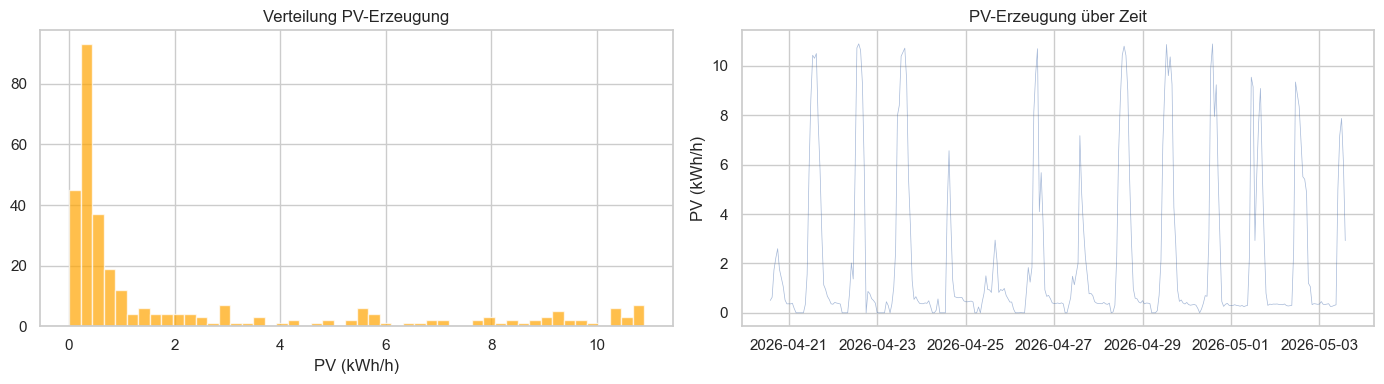

In [4]:
df = build_training_dataset(home, grid, weather)
print(f"Trainingsdatensatz: {len(df)} Zeilen, {len(df.columns)} Spalten")
print(f"Zeitraum: {df['timestamp'].min()} bis {df['timestamp'].max()}")
print(f"\nFeature-Spalten ({len(FEATURE_COLS)}):")
available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
print(f"  Verfügbar: {len(available)}")
if missing:
    print(f"  Fehlen: {missing}")

# PV-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["pv_kwh"], bins=50, color="orange", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("PV (kWh/h)")
axes[0].set_title("Verteilung PV-Erzeugung")

axes[1].plot(df["timestamp"], df["pv_kwh"], alpha=0.5, linewidth=0.5)
axes[1].set_ylabel("PV (kWh/h)")
axes[1].set_title("PV-Erzeugung über Zeit")

plt.tight_layout()
plt.show()

## 3. Modelltraining

In [8]:
# Bei nur ~13 Tagen Daten: 3 Tage Test, ~10 Tage Training
TEST_DAYS = 3

# --- Modell: Alle Features mit Regularisierung ---
model = PVForecastModel(params={
    "n_estimators": 150,
    "max_depth": 4,
    "learning_rate": 0.05,
    "num_leaves": 12,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "min_child_samples": 15,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "verbose": -1,
})
metrics = model.train(df, target="pv_kwh", test_days=TEST_DAYS)

print("=== Modell-Performance ===")
print(f"Training ({metrics['train_samples']} Samples, ~{metrics['train_samples']//24} Tage):")
print(f"  MAE:  {metrics['train_mae']:.3f} kWh")
print(f"  RMSE: {metrics['train_rmse']:.3f} kWh")
print(f"  R²:   {metrics['train_r2']:.4f}")
print(f"\nTest ({metrics['test_samples']} Samples, {TEST_DAYS} Tage):")
print(f"  MAE:  {metrics['test_mae']:.3f} kWh")
print(f"  RMSE: {metrics['test_rmse']:.3f} kWh")
print(f"  R²:   {metrics['test_r2']:.4f}")
if "baseline_mae" in metrics:
    print(f"\nBaseline (Persistence = gestern gleiche Stunde):")
    print(f"  MAE:  {metrics['baseline_mae']:.3f} kWh")
    improvement = (1 - metrics["test_mae"] / metrics["baseline_mae"]) * 100
    print(f"  Modell vs. Baseline: {improvement:+.1f}%")

print(f"\n⚠ Wenig Trainingsdaten ({metrics['train_samples']} Samples).")
print(f"  Performance wird mit täglichem Retraining und wachsender Datenbasis besser.")

=== Modell-Performance ===
Training (241 Samples, ~10 Tage):
  MAE:  0.158 kWh
  RMSE: 0.275 kWh
  R²:   0.9927

Test (72 Samples, 3 Tage):
  MAE:  0.838 kWh
  RMSE: 1.417 kWh
  R²:   0.7974

Baseline (Persistence = gestern gleiche Stunde):
  MAE:  0.894 kWh
  Modell vs. Baseline: +6.3%

⚠ Wenig Trainingsdaten (241 Samples).
  Performance wird mit täglichem Retraining und wachsender Datenbasis besser.


## 4. Evaluation

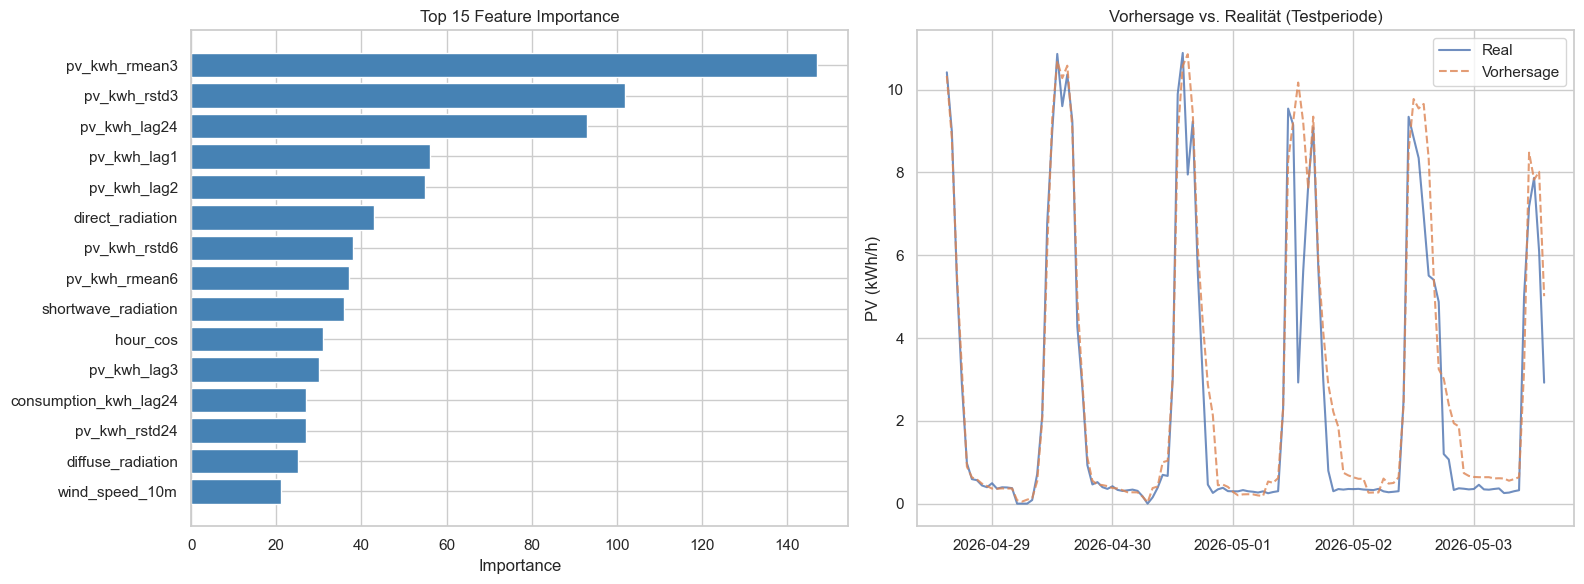

In [9]:
# Feature Importance
importance = model.feature_importance()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 Features
top15 = importance.head(15)
axes[0].barh(top15["feature"], top15["importance"], color="steelblue")
axes[0].set_xlabel("Importance")
axes[0].set_title("Top 15 Feature Importance")
axes[0].invert_yaxis()

# Vorhersage vs. Realität (Testperiode)
split_date = df["timestamp"].max() - pd.Timedelta(days=5)
test = df[df["timestamp"] > split_date].copy()
test["predicted"] = model.predict(test)

axes[1].plot(test["timestamp"], test["pv_kwh"], label="Real", alpha=0.8)
axes[1].plot(test["timestamp"], test["predicted"], label="Vorhersage", alpha=0.8, linestyle="--")
axes[1].set_ylabel("PV (kWh/h)")
axes[1].set_title("Vorhersage vs. Realität (Testperiode)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Modell speichern

In [10]:
path = model.save()
size_mb = path.stat().st_size / (1024 * 1024)
print(f"Modell gespeichert: {path}")
print(f"Größe: {size_mb:.2f} MB")
print(f"Pi4-kompatibel: {'✅ Ja' if size_mb < 20 else '❌ Nein'} (Limit: 20 MB)")

Modell gespeichert: d:\GitHub\OptimizePV\notebooks\..\models\pv_forecast.joblib
Größe: 0.12 MB
Pi4-kompatibel: ✅ Ja (Limit: 20 MB)
